# Analysis: 20251107

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cdk.analysis.cytosol import platereader as pr

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
data_file = "./20251107-cytation3-pure-timecourse-gfp-MgSweep-biotek-cdk.txt"
platemap_file = "./20251107-NucleusPURE-deGFP-MgSweep-platemap.csv"

data, platemap = pr.load_platereader_data(data_file, platemap_file)

# Basic Analysis

## Curves
Curves of RFU over time, by named sample.

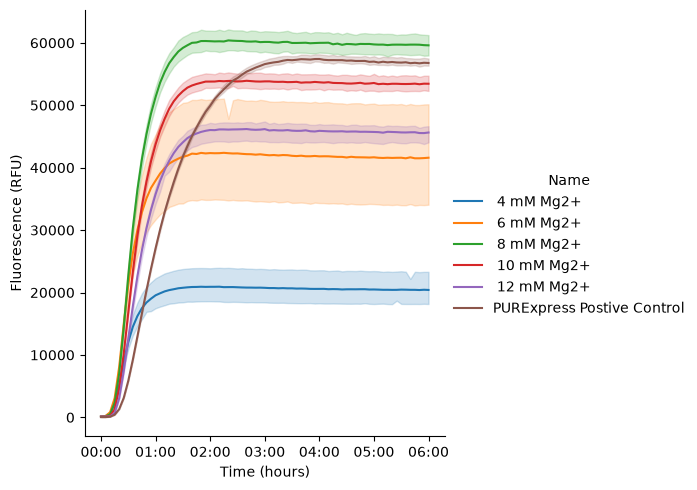

In [4]:
#| label: fig:kinetics-exp2

K=pr.plot_curves(data)
K.savefig('Kinetics')

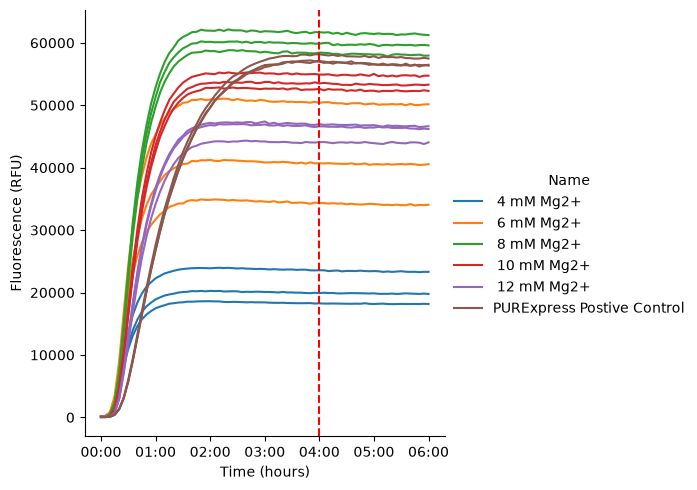

In [5]:
K=pr.plot_curves(data, units="Well", estimator=None)
K.axes.flatten()[0].axvline(pd.to_timedelta("04:00:00"), c="red", ls="--")
K.savefig('Kinetics2')

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

There's something weird going on with solving the kinetics. In the meantime, pick an appropriate-looking time for which to calculate steady state and use that. Here we chose four hours.

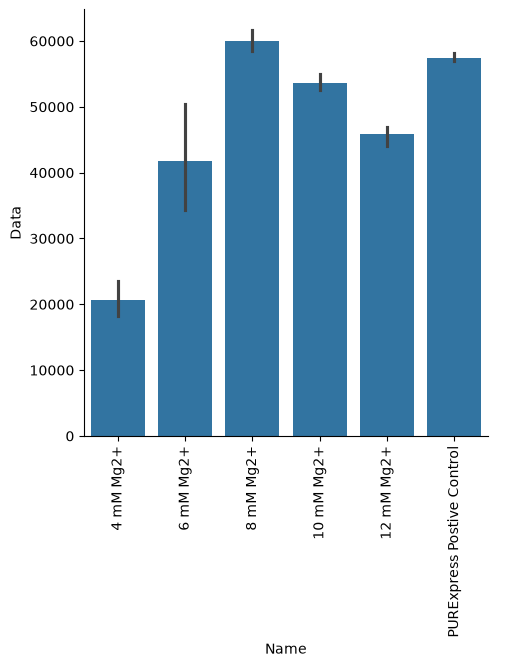

In [6]:
#| label: fig:endpoint-exp2

g = sns.catplot(
    data=data[data["Time"] == "04:00:00"],
    x="Name",
    y="Data",
    kind="bar"
)

g.set_xticklabels(rotation=90)
g.savefig('Steadystate')

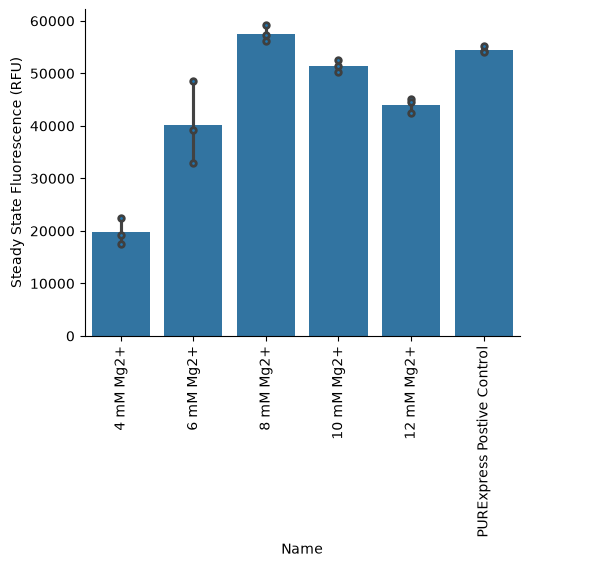

In [7]:
S= pr.plot_steadystate(data)
S.savefig('endpoint')

## Kinetics
These functions calculate key kinetic parameters of the time series.

In [8]:
data["Read"].unique()

array(['GFP-F-G35'], dtype=object)

In [9]:
pr.kinetic_analysis(data, group_by=["Well"])

Velocity                                         Lag  \
                          Time     Data      Max                      Time   
Well                                                                         
B10  0 days 00:27:39.127690260  9192.42 35229.55 0 days 00:11:59.782011727   
B12  0 days 00:27:43.051249782 10138.37 37157.67 0 days 00:11:20.801088528   
B14  0 days 00:28:33.766010655 11837.93 43980.30 0 days 00:12:24.773821614   
D10  0 days 00:29:23.447422773 17293.27 60560.09 0 days 00:12:15.447260347   
D12  0 days 00:30:46.405018101 20630.07 66660.31 0 days 00:12:12.274964506   
D14  0 days 00:31:27.283855339 25544.05 80829.33 0 days 00:12:29.595493450   
F10  0 days 00:35:38.492638641 30160.54 86897.15 0 days 00:14:48.993116802   
F12  0 days 00:35:28.883392526 31165.89 89568.65 0 days 00:14:36.244064184   
F14  0 days 00:35:51.285870106 29554.62 83478.07 0 days 00:14:36.739825245   
H10  0 days 00:38:28.682264936 27636.99 74344.32 0 days 00:16:10.406742063   
H12  0 days 00:38:40.346870683 27046.79 71270.89 0 days 00:15:54.172648990   
H14  0 days 00:39:02.188332878 26441.34 69933.30 0 days 00:16:21.051154290   
J10  0 days 00:40:58.037015780 22324.78 54560.20 0 days 00:16:24.999916868   
J12  0 days 00:40:51.829055425 23732.15 59092.05 0 days 00:16:46.021268027   
J14     0 days 00:42:55.673906 23399.68 58266.42 0 days 00:18:49.920955700   
L10  0 days 01:00:17.655535396 28572.32 39050.91 0 days 00:16:23.649294802   
L12  0 days 00:59:57.207575047 28478.50 38879.07 0 days 00:16:00.246316310   
L14  0 days 00:59:31.582831689 29050.87 39722.75 0 days 00:15:38.756388326   

                          Steady State           \
        Data                      Time     Data   
Well                                              
B10  1946.03 0 days 00:50:42.050705272 17465.60   
B12  1782.80 0 days 00:51:49.139079674 19262.90   
B14  2522.66 0 days 00:52:20.335195650 22492.07   
D10  3403.54 0 days 00:54:36.889296055 32857.22   
D12  3545.99 0 days 00:58:06.648996784 39197.14   
D14  4446.65 0 days 00:59:22.210834282 48533.70   
F10  5516.14 0 days 01:06:18.030185974 57305.03   
F12  5406.09 0 days 01:06:13.043424358 59215.20   
F14  5027.84 0 days 01:07:07.697397565 56153.78   
H10  5017.56 0 days 01:11:18.917570763 52510.29   
H12  4517.48 0 days 01:12:11.655185018 51388.91   
H14  4792.55 0 days 01:12:26.081013898 50238.54   
J10  3530.28 0 days 01:17:06.670940528 42417.08   
J12  4032.95 0 days 01:16:20.375457596 45091.08   
J14  5554.69 0 days 01:18:24.139576551 44459.39   
L10  2759.44 0 days 02:04:55.490857903 54287.41   
L12  2637.79 0 days 02:04:39.393333368 54109.15   
L14  2600.60 0 days 02:04:07.681233284 55196.64   

                                                    Fit                       
                                                 params  R^2  drift good_fit  
Well                                                                          
B10   [18384.84651683236, 7.664909911789614, 0.46086... 1.00  42.33     True  
B12   [20276.739358771836, 7.330108245084094, 0.4619... 0.99 109.15     True  
B14   [23675.86813093157, 7.43040045761027, 0.476046... 0.99  51.71     True  
D10   [34586.54334497583, 7.003889949217267, 0.48984... 0.99 124.11     True  
D12   [41260.144555549006, 6.462441236034682, 0.5128... 0.99 236.75     True  
D14   [51088.10700330671, 6.328622356833956, 0.52424... 0.99 283.71     True  
F10   [60321.081181049594, 5.762307130054482, 0.5940... 1.00 291.03     True  
F12   [62331.78504867434, 5.747863602961548, 0.59135... 1.00 351.60     True  
F14   [59109.24325181486, 5.649070137273777, 0.59757... 1.00 350.59     True  
H10   [55273.988141030204, 5.380058053806774, 0.6413... 1.00 289.88     True  
H12   [54093.58486242694, 5.270191670492156, 0.64454... 1.00 336.64     True  
H14   [52882.676262446716, 5.289694615579528, 0.6506... 1.00 266.38     True  
J10   [44649.55280169389, 4.88786060387154, 0.682788... 1.00 312.95     True  
J12   [47464.299550272786, 4.979915079217008, 0

(<seaborn.axisgrid.FacetGrid at 0x13e9fa0d0>,
                       Velocity                                         Lag  \
                           Time     Data      Max                      Time   
 Well                                                                         
 B10  0 days 00:27:39.127690260  9192.42 35229.55 0 days 00:11:59.782011727   
 B12  0 days 00:27:43.051249782 10138.37 37157.67 0 days 00:11:20.801088528   
 B14  0 days 00:28:33.766010655 11837.93 43980.30 0 days 00:12:24.773821614   
 D10  0 days 00:29:23.447422773 17293.27 60560.09 0 days 00:12:15.447260347   
 D12  0 days 00:30:46.405018101 20630.07 66660.31 0 days 00:12:12.274964506   
 D14  0 days 00:31:27.283855339 25544.05 80829.33 0 days 00:12:29.595493450   
 F10  0 days 00:35:38.492638641 30160.54 86897.15 0 days 00:14:48.993116802   
 F12  0 days 00:35:28.883392526 31165.89 89568.65 0 days 00:14:36.244064184   
 F14  0 days 00:35:51.285870106 29554.62 83478.07 0 days 00:14:36.739825245   
 H10  

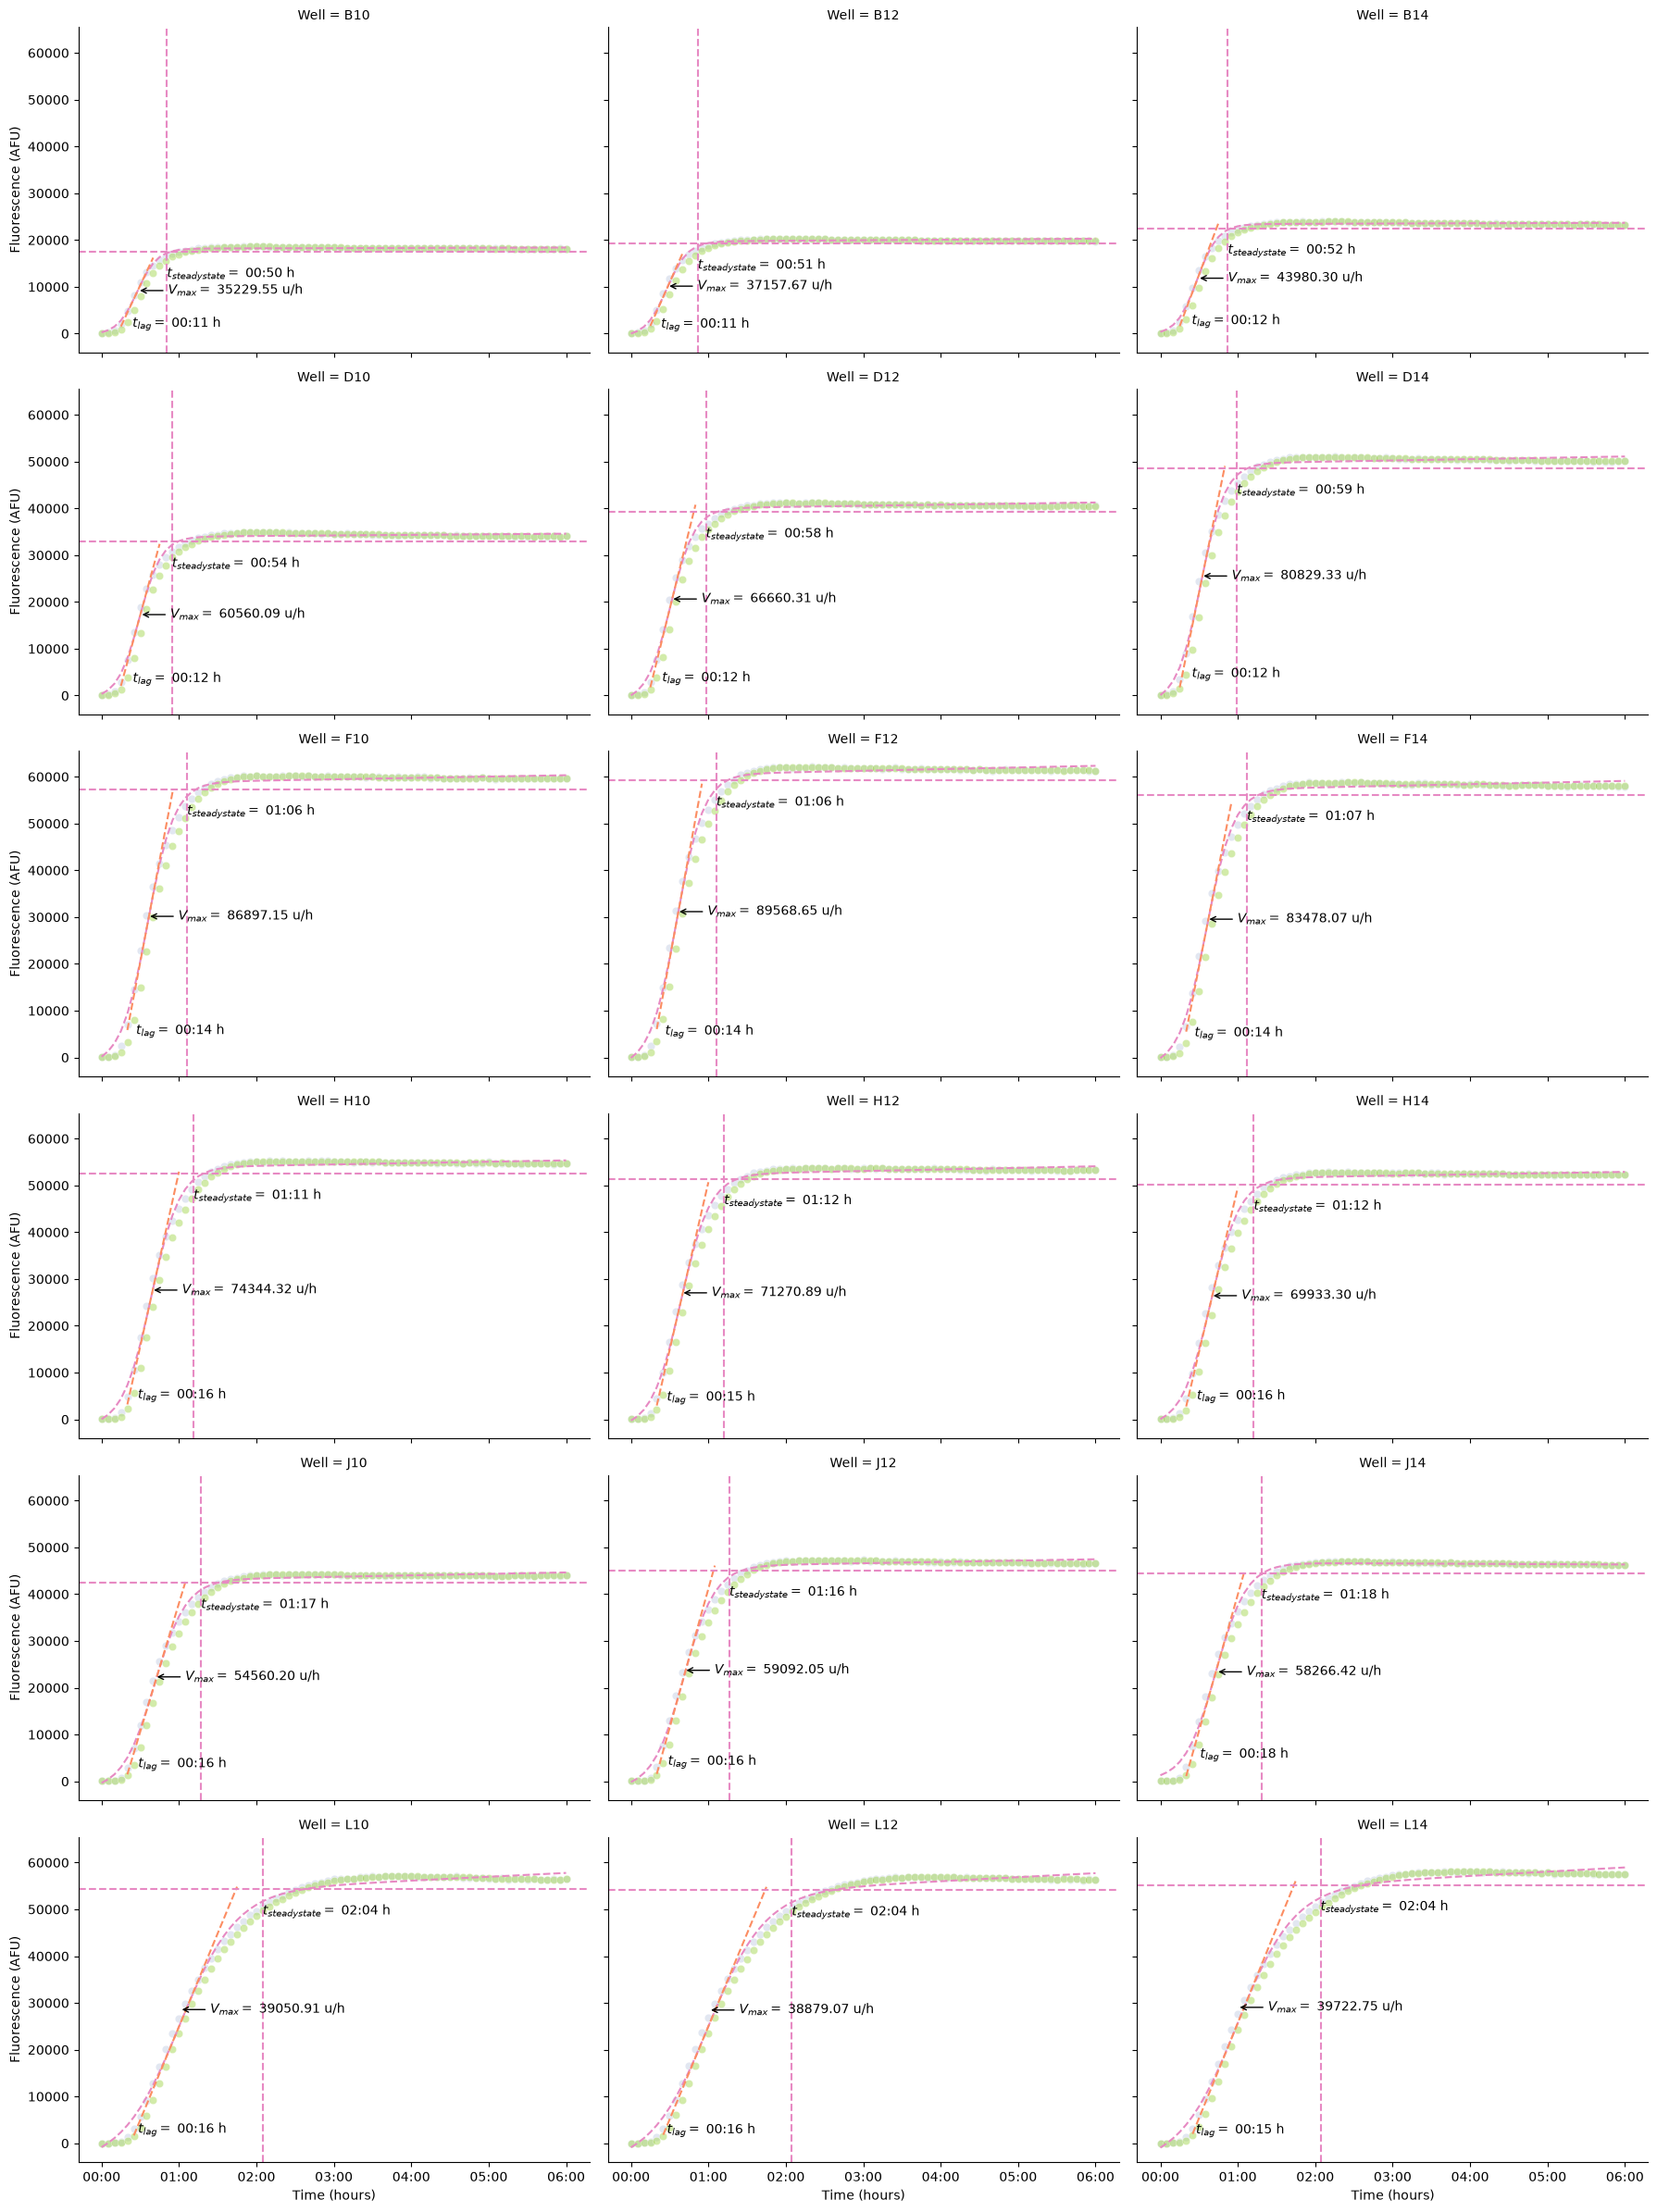

In [10]:
pr.plot_kinetics(data, group_by=["Well"])

We can also calculate the kinetics and display the parameters as a table.

In [11]:
pr.kinetic_analysis(data)

Velocity           \
                                                               Time     Data   
Name                       Read      Well                                      
 4 mM Mg2+                 GFP-F-G35 B10  0 days 00:27:39.127690260  9192.42   
                                     B12  0 days 00:27:43.051249782 10138.37   
                                     B14  0 days 00:28:33.766010655 11837.93   
 6 mM Mg2+                 GFP-F-G35 D10  0 days 00:29:23.447422773 17293.27   
                                     D12  0 days 00:30:46.405018101 20630.07   
                                     D14  0 days 00:31:27.283855339 25544.05   
 8 mM Mg2+                 GFP-F-G35 F10  0 days 00:35:38.492638641 30160.54   
                                     F12  0 days 00:35:28.883392526 31165.89   
                                     F14  0 days 00:35:51.285870106 29554.62   
 10 mM Mg2+                GFP-F-G35 H10  0 days 00:38:28.682264936 27636.99   
                                     H12  0 days 00:38:40.346870683 27046.79   
                                     H14  0 days 00:39:02.188332878 26441.34   
 12 mM Mg2+                GFP-F-G35 J10  0 days 00:40:58.037015780 22324.78   
                                     J12  0 days 00:40:51.829055425 23732.15   
                                     J14     0 days 00:42:55.673906 23399.68   
PURExpress Postive Control GFP-F-G35 L10  0 days 01:00:17.655535396 28572.32   
                                     L12  0 days 00:59:57.207575047 28478.50   
                                     L14  0 days 00:59:31.582831689 29050.87   

                                                                         Lag  \
                                               Max                      Time   
Name                       Read      Well                                      
 4 mM Mg2+                 GFP-F-G35 B10  35229.55 0 days 00:11:59.782011727   
                                     B12  37157.67 0 days 00:11:20.801088528   
                                     B14  43980.30 0 days 00:12:24.773821614   
 6 mM Mg2+                 GFP-F-G35 D10  60560.09 0 days 00:12:15.447260347   
                                     D12  66660.31 0 days 00:12:12.274964506   
                                     D14  80829.33 0 days 00:12:29.595493450   
 8 mM Mg2+                 GFP-F-G35 F10  86897.15 0 days 00:14:48.993116802   
                                     F12  89568.65 0 days 00:14:36.244064184   
                                     F14  83478.07 0 days 00:14:36.739825245   
 10 mM Mg2+                GFP-F-G35 H10  74344.32 0 days 00:16:10.406742063   
                                     H12  71270.89 0 days 00:15:54.172648990   
                                     H14  69933.30 0 days 00:16:21.051154290   
 12 mM Mg2+                GFP-F-G35 J10  54560.20 0 days 00:16:24.999916868   
                                     J12  59092.05 0 days 00:16:46.021268027   
                                     J14  58266.42 0 days 00:18:49.920955700   
PURExpress Postive Control GFP-F-G35 L10  39050.91 0 days 00:16:23.649294802   
                                     L12  38879.07 0 days 00:16:00.246316310   
                                     L14  39722.75 0 days 00:15:38.756388326   

                                                               Steady State  \
                                             Data                      Time   
Name                       Read      Well                                     
 4 mM Mg2+                 GFP-F-G35 B10  1946.03 0 days 00:50:42.050705272   
                                     B12  1782.80 0 days 00:51:49.139079674   
                                     B14  2522.66 0 days 00:52:20.335195650   
 6 mM Mg2+                 GFP-F-G35 D10  3403.54 0 days 00:54:36.889296055   
                                     D12  3545.99 0 days 00:58:06.648996784   
                                     D14  4446.65 0 days 00:59:22